### PS-S06E04: CatBoost

This notebook tackles the [**Playground Series – Season 6, Episode 4: Predicting Irrigation Need**](https://www.kaggle.com/competitions/playground-series-s6e4), a competition focused on predicting the irrigation needs of crops. The goal is to classify the required irrigation level into three categories: **Low (0), Medium (1), or High (2)**, based on environmental features including soil moisture, temperature, humidity, and crop variety.

CatBoost is a strong baseline for tabular problems and often complements XGBoost/LightGBM in ensembles because it handles categorical features natively and robustly.

In this notebook we:
- Apply lightweight, physics-based feature engineering per fold (to avoid leakage)
- Train a **CatBoostClassifier** using **Stratified 5-Fold Cross-Validation**.
- Optimize for **Balanced Accuracy**, the primary evaluation metric for this competition.
- Collect **Out-of-Fold (OOF) probabilities** and test-set predictions for downstream ensembling.

## Install Needed Packages

In [1]:
import os
import gc
import sys
import math
import random
import warnings

# Third-party
import numpy as np
import pandas as pd
import catboost as cb
import optuna
import torch
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score
from sklearn.feature_selection import RFECV
from catboost import CatBoostClassifier, Pool, EFstrType, EFeaturesSelectionAlgorithm, EShapCalcType

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e04_feature_engineering import FeatureFactory
from ps_s06e04_model_visualizer import ModelVisualizer
from ps_s06e04_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# Target label column for S06E03
TARGET = 'Irrigation_Need'

# GPU usage (set True only if your environment supports CatBoost GPU)
USE_GPU = False

# Optional: Recursive Feature Elimination
PERFORM_RFE = False

# Optional: Optuna tuning
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0   0     Loamy    4.920         32.580           1.010   
1   1      Clay    7.080         56.610           0.440   
2   2      Clay    5.690         27.710           0.810   
3   3     Sandy    5.650         13.320           1.330   
4   4      Clay    7.960         59.140           0.380   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                    3.050         15.010    50.610      725.990   
1                    2.000         22.920    67.860      985.660   
2                    2.830         26.970    92.220    2,201.700   
3                    0.870         13.320    61.570    1,357.330   
4                    0.960         20.220    91.110    1,538.200   

   Sunlight_Hours  Wind_Speed_kmh  Crop_Type Crop_Growth_Stage  Season  \
0           5.900          16.790  Sugarcane            Sowing    Zaid   
1           6.980           3.390      Wheat        Vegetative  Kharif

## Read and Examine the Test Dataset

In [4]:
test_df = helper.read_dataset('test')

TEST DATASET

       id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0  630000      Silt    6.360         26.190           0.590   
1  630001      Clay    5.870          9.880           1.180   
2  630002     Sandy    6.220         26.550           0.960   
3  630003      Clay    7.680         53.580           0.830   
4  630004     Loamy    5.230         59.020           0.540   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                    2.810         17.830    30.240    1,533.380   
1                    3.260         21.180    78.070      576.050   
2                    0.850         26.870    60.350      545.300   
3                    0.550         41.740    36.050    1,211.030   
4                    2.110         41.080    52.470    1,321.910   

   Sunlight_Hours  Wind_Speed_kmh Crop_Type Crop_Growth_Stage  Season  \
0           5.400           3.000     Maize            Sowing    Rabi   
1           7.220          15.880    Cotton         

## Feature Engineering Strategy

We apply a set of feature engineering steps designed to capture the relationship between soil conditions and atmospheric demand:

- `encoding`: Standardizes numeric features.
- `ratios`: Calculates features like the **Vapor Pressure Deficit (VPD)**, which represents the atmospheric "pull" on soil moisture.
- `interactions`: Creates terms between multiple features, such as a feature created based on `Soil_Type` and `Soil_Moisture` to account for varying water-holding capacities.
- `binning`: Groups continuous variables like `Temperature_C` into lifecycle stages.

**Categorical Handling**: We pass categorical fields like `Soil_Type`, `Crop_Type`, and `Region` directly to CatBoost. This allows the model to learn complex non-linear splits without the need for manual one-hot encoding.

In [5]:
# Define which feature engineering strategies to use
fe_strategies = [
        'encoding',
        'ratios',
        'interactions',
        'binning'
]

In [6]:
print('Performing initial feature engineering.')

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Encode target labels
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
y = training_df[TARGET].map(target_mapping).astype(int)

# Fit_transform on training, transform on test
X = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

cat_features = feature_engineer.get_cat_features(X)
print(f'Feature Count: {X.shape[1]}')
print(f'CatBoost categorical features ({len(cat_features)}): {cat_features}')
print(f'Target sample: {y.head()}')
display(X.head())

Performing initial feature engineering.
Feature Count: 23
CatBoost categorical features (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
Target sample: 0    0
1    0
2    0
3    1
4    0
Name: Irrigation_Need, dtype: int64


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,SVP,VPD,Water_Balance,Soil_Moisture_Interaction
0,Loamy,4.920,32.580,1.010,3.050,15.010,50.610,725.990,5.900,16.790,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.820,No,112.160,East,1.707,0.843,722.988,65.160
1,Clay,7.080,56.610,0.440,2.000,22.920,67.860,985.660,6.980,3.390,Wheat,Vegetative,Kharif,Rainfed,River,5.270,Yes,47.160,South,2.797,0.899,981.076,226.440
2,Clay,5.690,27.710,0.810,2.830,26.970,92.220,"2,201.700",6.050,3.850,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.240,Yes,110.380,North,3.560,0.277,"2,196.306",110.840
3,Sandy,5.650,13.320,1.330,0.870,13.320,61.570,"1,357.330",9.120,2.310,Wheat,Flowering,Kharif,Canal,River,8.320,Yes,53.850,South,1.530,0.588,"1,354.666",13.320
4,Clay,7.960,59.140,0.380,0.960,20.220,91.110,"1,538.200",6.950,13.940,Wheat,Sowing,Rabi,Canal,River,7.370,No,93.190,South,2.371,0.211,"1,534.156",236.560


In [7]:
# Categorical columns for this competition (integer-coded)
cat_cols = feature_engineer.get_cat_features(X)

cat_cols = [c for c in cat_cols if c in X.columns]
print(f'Categorical Features: {cat_cols}')

# CatBoost accepts categoricals as either int codes or strings. We keep strings here.
for c in cat_cols:
    # Convert all identified categorical columns to string
    X[c] = X[c].astype(str)
    X_test[c] = X_test[c].astype(str)

Categorical Features: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


### Recursive Feature Elimination (RFE)

Optionally run **RFECV** to remove features that do not contribute to ROC AUC.

- This is relatively expensive for boosting models.
- In practice, feature selection often helps less than careful regularization and early stopping.
- Keep this off unless you are explicitly experimenting.


In [8]:
n_jobs = 1 if USE_GPU else -1

optimal_cols = X.columns

if PERFORM_RFE:
    print('Running Recursive Feature Elimination (RFECV)...')

    FS_RANDOM_SEED = seed
    FS_STEPS = 5  # higher = slower, potentially more stable (try 5/10/20/30)
    FS_EVAL_SPLIT = 0.2  # simple holdout inside selection
    
    y_fs = y.astype(np.int8)

    # Recreate features using your FeatureFactory (same as training)
    fe_fs = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_fs = fe_fs.fit_transform(training_df)
    cat_features_fs = fe_fs.get_cat_features(X_fs)

    # Train/eval split for feature selection (stratified)
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=1, test_size=FS_EVAL_SPLIT, random_state=seed)
    tr_idx, va_idx = next(sss.split(X_fs, y_fs))

    X_tr_fs, y_tr_fs = X_fs.iloc[tr_idx], y_fs.iloc[tr_idx]
    X_va_fs, y_va_fs = X_fs.iloc[va_idx], y_fs.iloc[va_idx]

    train_pool_fs = Pool(X_tr_fs, y_tr_fs, cat_features=cat_features_fs)
    eval_pool_fs  = Pool(X_va_fs, y_va_fs, cat_features=cat_features_fs)

    # Base model for selection.
    # You can swap in your tuned params once you have them; keep it modest for speed.
    fs_model = CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='TotalF1',
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        random_seed=seed,
        auto_class_weights='Balanced', # Vital for Balanced Accuracy
        task_type='GPU' if USE_GPU else 'CPU',
        verbose=200,
        allow_writing_files=False,
    )

    # Select features
    # - RecursiveByShapValues: generally strong, slower
    # - RecursiveByLossFunctionChange: faster, often good enough
    fs_result = fs_model.select_features(
        train_pool_fs,
        eval_set=eval_pool_fs,
        features_for_select=list(range(X_tr_fs.shape[1])),  # select from all features
        num_features_to_select=int(X_tr_fs.shape[1] * 0.85),  # keep 85% (tune: 0.6–0.9)
        steps=FS_STEPS,
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
        shap_calc_type=EShapCalcType.Regular,
        train_final_model=False,
        logging_level="Verbose",
        plot=False
    )

    selected_idx = fs_result["selected_features"]
    optimal_cols = [X_fs.columns[i] for i in selected_idx]

    print(f"Selected {len(optimal_cols)} / {X_fs.shape[1]} features.")
    print("Selected columns:")
    print(optimal_cols[:30])

else:
    optimal_cols = [
        'Soil_Type',
        'Soil_pH',
        'Soil_Moisture',
        'Organic_Carbon',
        'Electrical_Conductivity',
        'Temperature_C',
        'Humidity',
        'Rainfall_mm',
        'Sunlight_Hours',
        'Wind_Speed_kmh',
        'Crop_Type',
        'Crop_Growth_Stage',
        'Irrigation_Type',
        'Water_Source',
        'Mulching_Used',
        'Previous_Irrigation_mm',
        'SVP',
        'VPD',
        'Water_Balance'
    ]
    print("Recursive Feature Elimination (RFECV) skipped.")

print('\nOptimal Features:')
print(optimal_cols)

Recursive Feature Elimination (RFECV) skipped.

Optimal Features:
['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Previous_Irrigation_mm', 'SVP', 'VPD', 'Water_Balance']


### Optuna: Hyperparameter Tuning

This section tunes CatBoost hyperparameters to maximize **Balanced Accuracy**.

- **Objective**: Maximize the arithmetic mean of class-specific recall scores.
- **Weights**: We use `auto_class_weights='Balanced'` to ensure the model does not ignore minority classes.
- **Validation**: Each trial runs a 5-fold stratified CV loop to ensure results are robust against class distribution shifts.


In [9]:
# Ensure optimal_cols is a standard list for filtering
cols_to_keep = list(optimal_cols) if optimal_cols is not None else None

print(f'Training shape: {X.shape}')
# print(f'Categorical Features: {cat_cols}')
print(f'cols_to_keep: {cols_to_keep}')

def objective(trial):

    params = {
        'loss_function': 'MultiClass',
        'eval_metric': 'TotalF1',
        'classes_count': 3,
        'auto_class_weights': 'Balanced',
        'iterations': 2500,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05),
        'depth': trial.suggest_int('depth', 3, 6),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 50.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1.0, 10.0),
        'border_count': trial.suggest_int('border_count', 64, 128),
        'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 20),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 200, log=True),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 10),
        'bootstrap_type': 'Bernoulli',
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'grow_policy': 'SymmetricTree',
        'task_type': 'GPU' if USE_GPU else 'CPU',
        'gpu_ram_part': 0.65,
        'metric_period': 20,
        'allow_writing_files': False,
        'random_seed': seed,
        'verbose': 0,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    fold_scores = []

    for train_idx, val_idx in cv.split(training_df, y):
        X_train_fold = training_df.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        
        X_val_fold = training_df.iloc[val_idx]
        y_val_fold = y.iloc[val_idx]
        
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
        
        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        if cols_to_keep is not None:
            final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
            if not final_cols:
                raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
            X_train_trans = X_train_trans[final_cols]
            X_val_trans = X_val_trans[final_cols]

        # Get categorical feature names from the fold's feature engineer
        cat_features_fold = fe_fold.get_cat_features(X_train_trans)
        
        # If you filter columns, keep cat_features consistent
        if cols_to_keep is not None:
            cat_features_fold = [c for c in cat_features_fold if c in final_cols]
        
        train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_features_fold)
        val_pool   = Pool(X_val_trans, y_val_fold,   cat_features=cat_features_fold)

        model = CatBoostClassifier(**params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=200,
            verbose=False
        )
        
        # If using GPU, ensure clean memory for Optuna trials
        if params.get('task_type') == 'GPU':
            torch.cuda.synchronize()

        val_preds = model.predict(val_pool)
        score = balanced_accuracy_score(y_val_fold, val_preds)
        fold_scores.append(score)

        del model, train_pool, val_pool
        gc.collect()
        
    return np.mean(fold_scores)

Training shape: (630000, 23)
cols_to_keep: ['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Previous_Irrigation_mm', 'SVP', 'VPD', 'Water_Balance']


In [10]:
if PERFORM_OPTUNA_TUNING:
    print('Starting Optuna Optimization...')

    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)

    study = optuna.create_study(
        study_name='cb_predict_irrigation_need_optuna',
        direction='maximize',
        pruner=pruner
    )

    study.optimize(
        objective,
        n_trials=50,
        n_jobs=1,
        gc_after_trial=True,
        show_progress_bar=True,
        timeout=18000
    )

    print('Best Score:', study.best_value)
    print('Best Params:', study.best_params)

    best_params = study.best_params
else:
    # Provide reasonable defaults if you are skipping Optuna
    best_params = {
        'learning_rate': 0.046883598428696535,
        'depth': 3,
        'l2_leaf_reg': 6.708262703036303,
        'random_strength': 2.7150187822139698,
        'border_count': 128,
        'one_hot_max_size': 9,
        'min_data_in_leaf': 14,
        'leaf_estimation_iterations': 1,
        'subsample': 0.8575312297264754
    }
    
    print('Using default params:')
    print(best_params)

Using default params:
{'learning_rate': 0.046883598428696535, 'depth': 3, 'l2_leaf_reg': 6.708262703036303, 'random_strength': 2.7150187822139698, 'border_count': 128, 'one_hot_max_size': 9, 'min_data_in_leaf': 14, 'leaf_estimation_iterations': 1, 'subsample': 0.8575312297264754}


### Model Training: Stratified Cross-Validation

Final training uses **5-fold StratifiedKFold**. Within each fold we:

- Fit the feature engineering pipeline on the training split and transform validation/test (leakage prevention)
- Train a `CatBoostClassifier` with early stopping on validation score
- Store **OOF probabilities** and averaged **test probabilities** for ensembling

The overall CV score is computed as balanced accuracy score on the full OOF vector.


In [11]:
# Cross-Validation Training Loop

# TARGET MAPPING REFERENCE:
# 0: Low Irrigation Need
# 1: Medium Irrigation Need
# 2: High Irrigation Need

# Number of iterations between reporting training metrics.
metric_period = 20

cb_tuned_params = {
    **best_params,
    'iterations': 8000,
    'loss_function': 'MultiClass',
    'eval_metric': 'TotalF1',
    'classes_count': 3,
    'auto_class_weights': 'Balanced',
    'bootstrap_type': 'Bernoulli',
    'grow_policy': 'SymmetricTree',
    'allow_writing_files': False,
    'random_seed': seed,
    'verbose': 200,
    'metric_period': metric_period,
    'task_type': 'GPU' if USE_GPU else 'CPU',
}

print('Final CatBoost CV Training with OOF / Test probabilities')
print('========================================================')
print('Parameters used for training:')
print(cb_tuned_params)

cols_to_keep = list(optimal_cols) if optimal_cols is not None else None

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

eval_results = []
models = []

oof_probs = np.zeros((len(y), 3), dtype=np.float64)
test_probs = np.zeros((len(test_df), 3), dtype=np.float64)
oof_preds = np.zeros(len(y), dtype=np.int32)

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y)):
    print(f'Starting fold {fold+1}/{n_folds}...')

    X_train_fold = training_df.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    
    X_val_fold = training_df.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]
    
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)

    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans = X_val_trans[final_cols]
        X_test_trans = X_test_trans[final_cols]

    cat_features_fold = fe_fold.get_cat_features(X_train_trans)
    if cols_to_keep is not None:
        cat_features_fold = [c for c in cat_features_fold if c in final_cols]
    
    train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_features_fold)
    val_pool = Pool(X_val_trans, y_val_fold, cat_features=cat_features_fold)
    test_pool = Pool(X_test_trans, cat_features=cat_features_fold)

    model = cb.CatBoostClassifier(**cb_tuned_params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=200,
        verbose=200
    )

    eval_results.append(model.get_evals_result())
    models.append(model)

    val_prob = model.predict_proba(val_pool) # Returns (N, 3) array
    val_pred = model.predict(val_pool).flatten() # Returns (N,) class labels

    oof_probs[val_idx] = val_prob
    oof_preds[val_idx] = val_pred

    fold_score = balanced_accuracy_score(y_val_fold, val_pred)
    print(f'Fold {fold+1} Balanced Accuracy: {fold_score:.6f}')

    test_prob_fold = model.predict_proba(test_pool)
    test_probs += test_prob_fold / n_folds

    del model, train_pool, val_pool
    gc.collect()
    
overall_score = balanced_accuracy_score(y, oof_preds)
print(f'Overall CV Balanced Accuracy: {overall_score:.6f}')

Final CatBoost CV Training with OOF / Test probabilities
Parameters used for training:
{'learning_rate': 0.046883598428696535, 'depth': 3, 'l2_leaf_reg': 6.708262703036303, 'random_strength': 2.7150187822139698, 'border_count': 128, 'one_hot_max_size': 9, 'min_data_in_leaf': 14, 'leaf_estimation_iterations': 1, 'subsample': 0.8575312297264754, 'iterations': 8000, 'loss_function': 'MultiClass', 'eval_metric': 'TotalF1', 'classes_count': 3, 'auto_class_weights': 'Balanced', 'bootstrap_type': 'Bernoulli', 'grow_policy': 'SymmetricTree', 'allow_writing_files': False, 'random_seed': 10301, 'verbose': 200, 'metric_period': 20, 'task_type': 'CPU'}
Starting fold 1/5...


0:	learn: 0.7475410	test: 0.7483046	best: 0.7483046 (0)	total: 214ms	remaining: 28m 31s
200:	learn: 0.9608019	test: 0.9604720	best: 0.9604998 (197)	total: 19.8s	remaining: 12m 49s
400:	learn: 0.9638606	test: 0.9631696	best: 0.9633333 (396)	total: 38.8s	remaining: 12m 15s
600:	learn: 0.9662801	test: 0.9650009	best: 0.9650009 (600)	total: 57.5s	remaining: 11m 48s
800:	learn: 0.9677279	test: 0.9665348	best: 0.9665348 (800)	total: 1m 15s	remaining: 11m 20s
1000:	learn: 0.9691655	test: 0.9671092	best: 0.9671883 (994)	total: 1m 33s	remaining: 10m 57s
1200:	learn: 0.9698538	test: 0.9677230	best: 0.9677230 (1200)	total: 1m 52s	remaining: 10m 35s
1400:	learn: 0.9706318	test: 0.9683035	best: 0.9684996 (1381)	total: 2m 10s	remaining: 10m 15s
1600:	learn: 0.9713721	test: 0.9684521	best: 0.9686631 (1475)	total: 2m 29s	remaining: 9m 57s
1800:	learn: 0.9721054	test: 0.9686007	best: 0.9687124 (1643)	total: 2m 47s	remaining: 9m 36s
2000:	learn: 0.9726070	test: 0.9686148	best: 0.9687845 (1951)	total: 3m

0:	learn: 0.7494194	test: 0.7489850	best: 0.7489850 (0)	total: 150ms	remaining: 20m
200:	learn: 0.9609654	test: 0.9638267	best: 0.9639166 (180)	total: 19.4s	remaining: 12m 33s
400:	learn: 0.9634856	test: 0.9660588	best: 0.9662233 (393)	total: 38.4s	remaining: 12m 8s
600:	learn: 0.9658368	test: 0.9680075	best: 0.9681059 (596)	total: 57.3s	remaining: 11m 45s
800:	learn: 0.9673922	test: 0.9691589	best: 0.9692380 (795)	total: 1m 15s	remaining: 11m 19s
1000:	learn: 0.9685147	test: 0.9698478	best: 0.9698927 (995)	total: 1m 33s	remaining: 10m 57s
1200:	learn: 0.9696219	test: 0.9702001	best: 0.9703777 (1156)	total: 1m 52s	remaining: 10m 36s
1400:	learn: 0.9704200	test: 0.9704928	best: 0.9706203 (1275)	total: 2m 10s	remaining: 10m 16s
1600:	learn: 0.9713503	test: 0.9707858	best: 0.9708184 (1577)	total: 2m 29s	remaining: 9m 57s
1800:	learn: 0.9719868	test: 0.9709721	best: 0.9709985 (1777)	total: 2m 47s	remaining: 9m 37s
2000:	learn: 0.9725330	test: 0.9709862	best: 0.9711076 (1983)	total: 3m 6s	r

0:	learn: 0.7486590	test: 0.7494284	best: 0.7494284 (0)	total: 132ms	remaining: 17m 33s
200:	learn: 0.9609663	test: 0.9602352	best: 0.9605711 (183)	total: 19.3s	remaining: 12m 29s
400:	learn: 0.9636750	test: 0.9637426	best: 0.9637426 (400)	total: 38.2s	remaining: 12m 4s
600:	learn: 0.9659381	test: 0.9658448	best: 0.9659291 (599)	total: 57s	remaining: 11m 41s
800:	learn: 0.9672756	test: 0.9673787	best: 0.9673787 (800)	total: 1m 15s	remaining: 11m 17s
1000:	learn: 0.9684544	test: 0.9685686	best: 0.9686592 (997)	total: 1m 33s	remaining: 10m 55s
1200:	learn: 0.9693485	test: 0.9692131	best: 0.9693978 (1156)	total: 1m 51s	remaining: 10m 33s
1400:	learn: 0.9702586	test: 0.9697485	best: 0.9698417 (1398)	total: 2m 10s	remaining: 10m 12s
1600:	learn: 0.9711335	test: 0.9703290	best: 0.9705831 (1588)	total: 2m 28s	remaining: 9m 52s
1800:	learn: 0.9719119	test: 0.9709473	best: 0.9709755 (1785)	total: 2m 46s	remaining: 9m 33s
2000:	learn: 0.9727762	test: 0.9711121	best: 0.9712922 (1869)	total: 3m 5s

0:	learn: 0.7502693	test: 0.7466631	best: 0.7466631 (0)	total: 146ms	remaining: 19m 27s
200:	learn: 0.9618745	test: 0.9597002	best: 0.9598423 (196)	total: 19.3s	remaining: 12m 27s
400:	learn: 0.9652596	test: 0.9622219	best: 0.9622501 (395)	total: 38.1s	remaining: 12m 2s
600:	learn: 0.9677015	test: 0.9634328	best: 0.9635427 (591)	total: 56.8s	remaining: 11m 39s
800:	learn: 0.9689340	test: 0.9643904	best: 0.9643904 (798)	total: 1m 15s	remaining: 11m 15s
1000:	learn: 0.9702665	test: 0.9652784	best: 0.9655143 (983)	total: 1m 33s	remaining: 10m 56s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.9655142557
bestIteration = 983

Shrink model to first 984 iterations.
Fold 4 Balanced Accuracy: 0.965519
Starting fold 5/5...


0:	learn: 0.7478489	test: 0.7505623	best: 0.7505623 (0)	total: 184ms	remaining: 24m 30s
200:	learn: 0.9604271	test: 0.9606751	best: 0.9610633 (193)	total: 19.5s	remaining: 12m 35s
400:	learn: 0.9639587	test: 0.9639377	best: 0.9639984 (399)	total: 38.1s	remaining: 12m 1s
600:	learn: 0.9664487	test: 0.9656468	best: 0.9658727 (592)	total: 56.6s	remaining: 11m 36s
800:	learn: 0.9676102	test: 0.9673351	best: 0.9673721 (790)	total: 1m 14s	remaining: 11m 12s
1000:	learn: 0.9688769	test: 0.9674703	best: 0.9676690 (971)	total: 1m 32s	remaining: 10m 48s
1200:	learn: 0.9701682	test: 0.9681028	best: 0.9682258 (1177)	total: 1m 50s	remaining: 10m 26s
1400:	learn: 0.9707710	test: 0.9686195	best: 0.9686309 (1377)	total: 2m 8s	remaining: 10m 6s
1600:	learn: 0.9714278	test: 0.9688064	best: 0.9689603 (1578)	total: 2m 26s	remaining: 9m 46s
1800:	learn: 0.9721617	test: 0.9694593	best: 0.9694593 (1800)	total: 2m 44s	remaining: 9m 26s
2000:	learn: 0.9727387	test: 0.9695584	best: 0.9696612 (1939)	total: 3m 2s

## Visualizing Model Performance

We use diagnostic plots to evaluate how well the model distinguishes between the three irrigation levels and to detect potential biases or over-fitting.

### Learning Curves (Train vs. Validation Balanced Accuracy)
This plot shows the **Balanced Accuracy** over boosting iterations. A widening gap between the blue (train) and red (validation) lines indicates overfitting. Because we use early_stopping_rounds, the model terminates once the validation score plateaus.

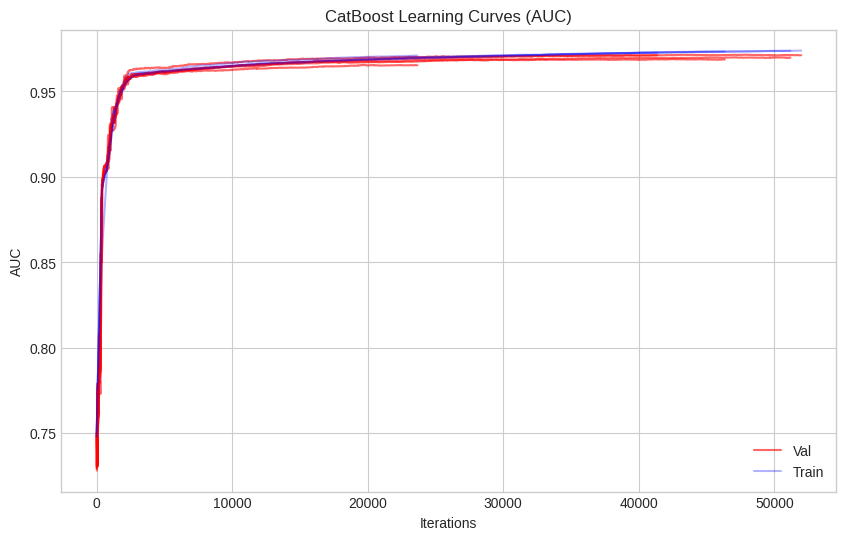

In [12]:
mviz = ModelVisualizer(model_name='CatBoost')

mviz.plot_learning_curves(eval_results, metric='auc', metric_period=metric_period)

### Feature Importance
Average feature importance across folds. This is a sanity check (not a causal explanation).

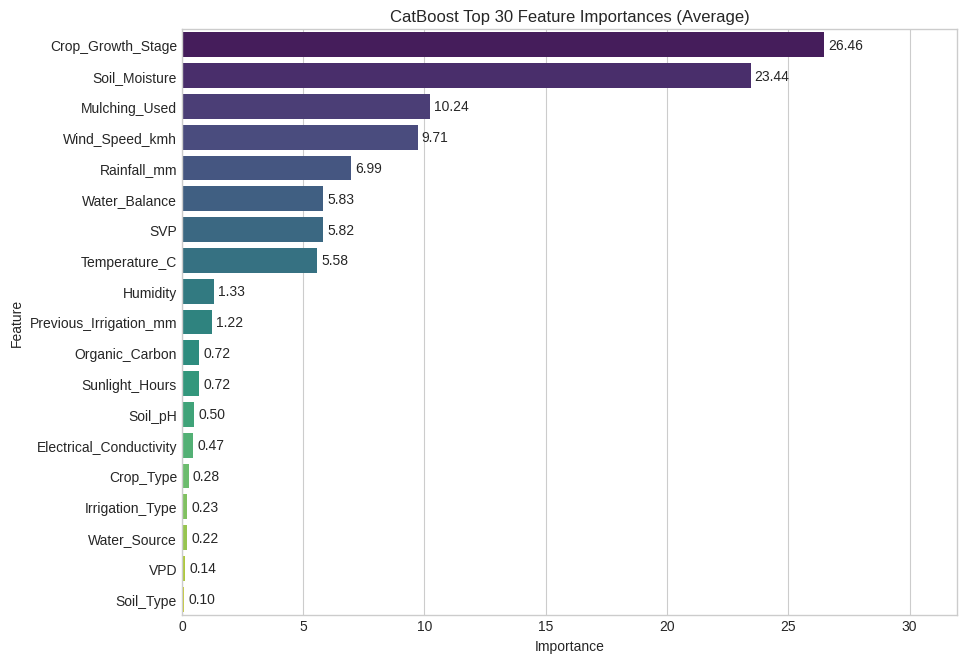

In [13]:
mviz.plot_feature_importance(models, show_values=True)

### Distribution Mismatch
Check if the model is over-predicting a specific irrigation level.  `y` is the actual ground truth, `oof_preds` is the argmax predictions.

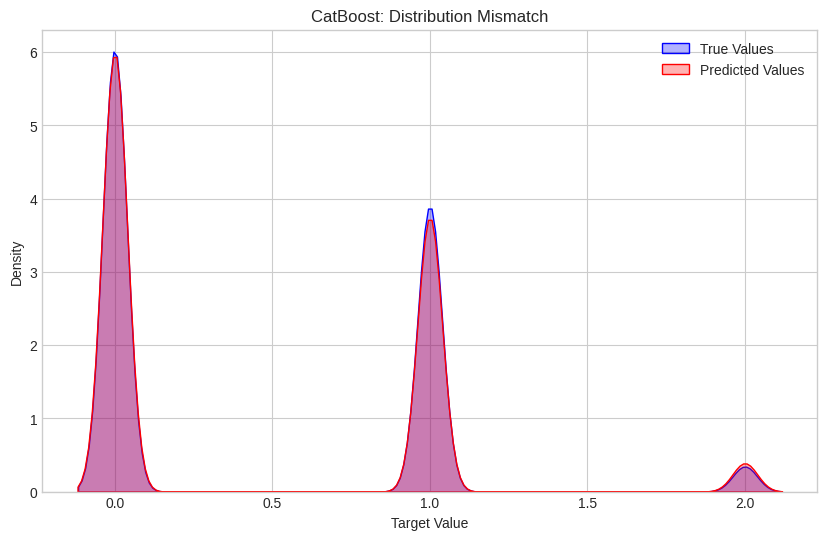

In [14]:
mviz.plot_distribution_mismatch(y_true=y, y_preds=oof_preds)

### ROC Curves (One-vs-Rest)
The ROC curve visualizes the trade-off between the True Positive Rate and False Positive Rate for each class. In this multi-class setting, we look for high AUC scores across all three irrigation levels.

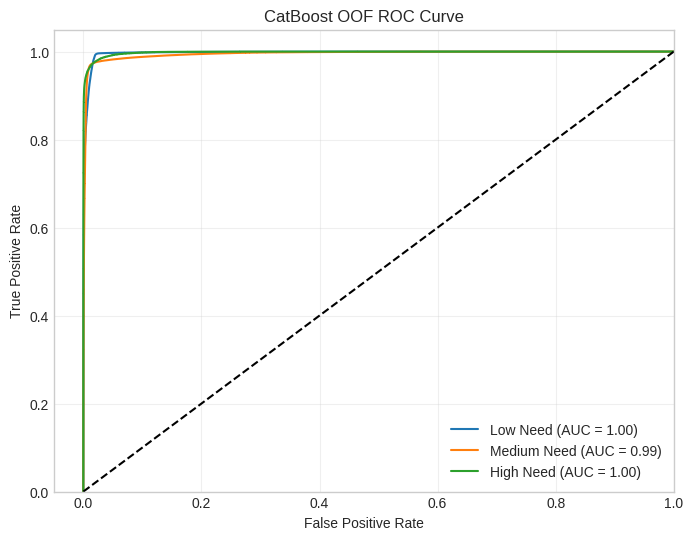

In [15]:
mviz.plot_multiclass_roc_curve(y_true=y, y_score=oof_probs, title='CatBoost OOF ROC Curve')

### Confusion Matrix (Out-of-Fold)
The confusion matrix helps identify specific error modes by showing which classes the model frequently confuses. For example, it reveals if the model often predicts "Medium Irrigation" when the actual need is "High." Since this is a multi-class task, predictions are determined by selecting the class with the highest predicted probability (**Argmax**).

Normalized confusion matrix


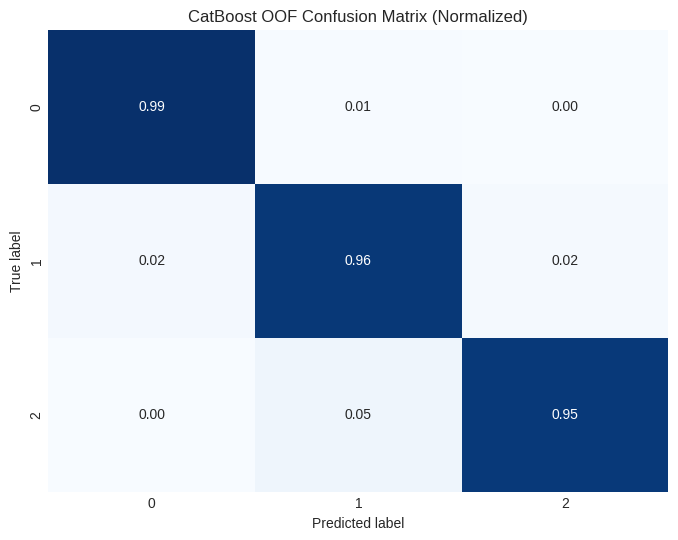

In [16]:
mviz.plot_confusion_matrix(y_true=y, y_pred=oof_preds, classes=[0,1,2], normalize=True, title='CatBoost OOF Confusion Matrix (Normalized)')

## Prepare Submission

We generate the final submission file according to the competition's schema. Since the evaluation metric is Balanced Accuracy, the submission requires the hard predicted class for each crop:

- **0**: Low Irrigation Need
- **1**: Medium Irrigation Need
- **2**: High Irrigation Need

The predictions are derived by selecting the class with the highest predicted probability (**Argmax**) for each sample in the test set.

In [17]:
submission_df = helper.read_dataset('submission')

target_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
numeric_preds = np.argmax(test_probs, axis=1)

# Identify the prediction column from the sample submission
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(numeric_preds).map(target_mapping)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))

SAMPLE SUBMISSION


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,High
9,630009,Low


In [18]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

Out-of-fold (OOF) probabilities and averaged test-set probabilities are saved for downstream ensembling (blending or stacking).
  
For this multi-class task, we save the full probability distribution (the confidence scores for categories 0, 1, and 2) rather than just the final predicted labels. Saving the raw probabilities is essential for:

- **Weighted Blending**: Combining multiple models by averaging their confidence scores.
- **Stacking**: Using these probabilities as "meta-features" for a secondary model.
- **Calibration Analysis**: Evaluating how well the model's confidence aligns with actual agricultural outcomes.


In [19]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Define column names for the probabilities
prob_cols = ['prob_low', 'prob_medium', 'prob_high']

# Save OOF probabilities
# Create a DF for the probabilities first
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)

# Combine with ID and Target
oof_df = pd.concat([
    pd.DataFrame({
        'id': training_df['id'].values,
        'target': y.values
    }),
    oof_prob_df
], axis=1)

oof_df.to_csv(f'{output_dir}/catboost_oof_probs.csv', index=False)

# Save Test probabilities
test_prob_values_df = pd.DataFrame(test_probs, columns=prob_cols)

test_prob_df = pd.concat([
    pd.DataFrame({
        'id': test_df['id'].values
    }),
    test_prob_values_df
], axis=1)
test_prob_df.to_csv(f'{output_dir}/catboost_test_probs.csv', index=False)

print(f'Saved for ensembling:\n - {output_dir}/catboost_oof_probs.csv\n - {output_dir}/catboost_test_probs.csv')

Saved for ensembling:
 - predictions/catboost_oof_probs.csv
 - predictions/catboost_test_probs.csv
